# Coffee Pharmacognosy: The Reference Library

What compounds are in coffee, what do they do pharmacologically, and how do
varieties differ — building the context needed to study how fermentation
and processing shape bioactive outcomes.

This notebook analyzes five scraped datasets:
- **Phenol-Explorer** — polyphenol concentrations in coffee
- **FooDB** — full chemical inventory (16,340 records)
- **PubChem** — bioassay results for 5 key compounds
- **ChEMBL** — bioactivity measurements against protein targets
- **World Coffee Research** — 70 arabica variety profiles

Cross-referenced with existing **CQI** (~1,300 coffees) and **Cup of Excellence** (~17,000 lots) data.

In [1]:
import sys
sys.path.insert(0, "..")

import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

pd.set_option("display.max_columns", 20)

# Load all datasets
phenol = pd.read_csv("../data/raw/phenol_explorer.csv")
foodb = pd.read_csv("../data/raw/foodb_coffee.csv")
props = pd.read_csv("../data/raw/pubchem_properties.csv")
bioassays = pd.read_csv("../data/raw/pubchem_coffee_bioassays.csv")
chembl = pd.read_csv("../data/raw/chembl_coffee_bioactivity.csv")
wcr = pd.read_csv("../data/raw/wcr_varieties.csv")

# Load existing datasets if available
import os
cqi = pd.read_csv("../data/raw/df_arabica_clean.csv") if os.path.exists("../data/raw/df_arabica_clean.csv") else None
coe = pd.read_csv("../data/raw/cup_of_excellence.csv", low_memory=False) if os.path.exists("../data/raw/cup_of_excellence.csv") else None
if coe is not None:
    coe["score"] = pd.to_numeric(coe["score"], errors="coerce")

print(f"Phenol-Explorer: {len(phenol)} compound entries across {phenol['food_name'].nunique()} coffee types")
print(f"FooDB:           {len(foodb)} compound-food records across {foodb['food_name'].nunique()} coffee types")
print(f"PubChem:         {len(bioassays)} bioassay results for {bioassays['compound_name'].nunique()} compounds")
print(f"ChEMBL:          {len(chembl)} bioactivity records for {chembl['compound_name'].nunique()} compounds")
print(f"WCR Varieties:   {len(wcr)} arabica varieties")
if cqi is not None:
    print(f"CQI:             {len(cqi)} coffees from {cqi['Country of Origin'].nunique()} countries")
if coe is not None:
    print(f"Cup of Exc.:     {len(coe)} competition lots")

Phenol-Explorer: 69 compound entries across 4 coffee types
FooDB:           16340 compound-food records across 4 coffee types
PubChem:         5510 bioassay results for 5 compounds
ChEMBL:          3333 bioactivity records for 5 compounds
WCR Varieties:   70 arabica varieties
CQI:             207 coffees from 22 countries
Cup of Exc.:     17211 competition lots


---

## 1. What's in Coffee? The Polyphenol Profile

Coffee is one of the richest dietary sources of polyphenols — particularly
**chlorogenic acids (CGAs)**, which are esters of caffeic acid and quinic acid.
A single cup of filter coffee contains ~200-280 mg of total polyphenols.

> **Why this matters for pharmacognosy:** CGAs are the compounds most affected
> by fermentation and roasting. Understanding the baseline profile tells us
> what's at stake when processing decisions are made.

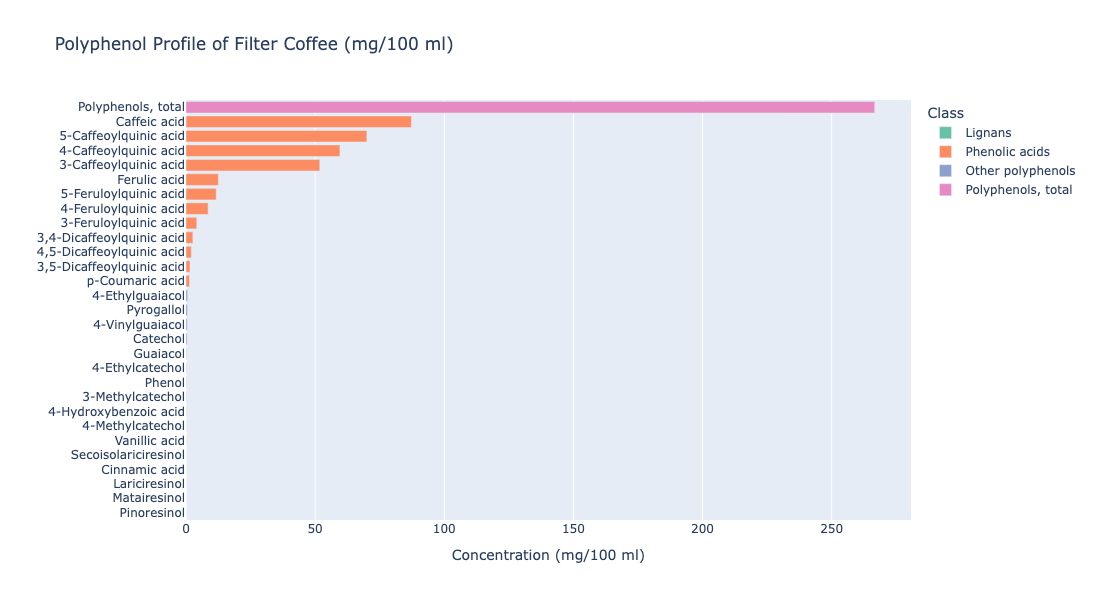

In [2]:
# Polyphenol profile of filter coffee (Phenol-Explorer)
general = phenol[phenol["food_name"] == "Coffee beverage [Filter]"].copy()
general = general[general["mean_content"] > 0].sort_values("mean_content", ascending=True)

fig = px.bar(
    general,
    x="mean_content",
    y="compound_name",
    color="polyphenol_class",
    orientation="h",
    title="Polyphenol Profile of Filter Coffee (mg/100 ml)",
    labels={"mean_content": "Concentration (mg/100 ml)", "compound_name": "", "polyphenol_class": "Class"},
    color_discrete_sequence=px.colors.qualitative.Set2,
)
fig.update_layout(height=600, yaxis=dict(categoryorder="total ascending"), showlegend=True)
fig.show()

Three caffeoylquinic acids dominate — **5-CQA (70 mg), 4-CQA (60 mg), and 3-CQA (52 mg)** —
together accounting for ~68% of total polyphenols. These are the primary chlorogenic acids,
and they're the ones most degraded during roasting (40-80% loss depending on roast level).

The feruloylquinic acids are present at lower but still meaningful levels (4-12 mg).
Lignans (secoisolariciresinol, lariciresinol) are trace but pharmacologically relevant.

---

## 2. Arabica vs Robusta — Two Different Chemical Profiles

Arabica and Robusta aren't just different in taste — they're chemically distinct
species. Understanding these differences matters because variety-level chemical
variation (e.g., Geisha vs Bourbon within Arabica) likely follows similar patterns
at a smaller scale.

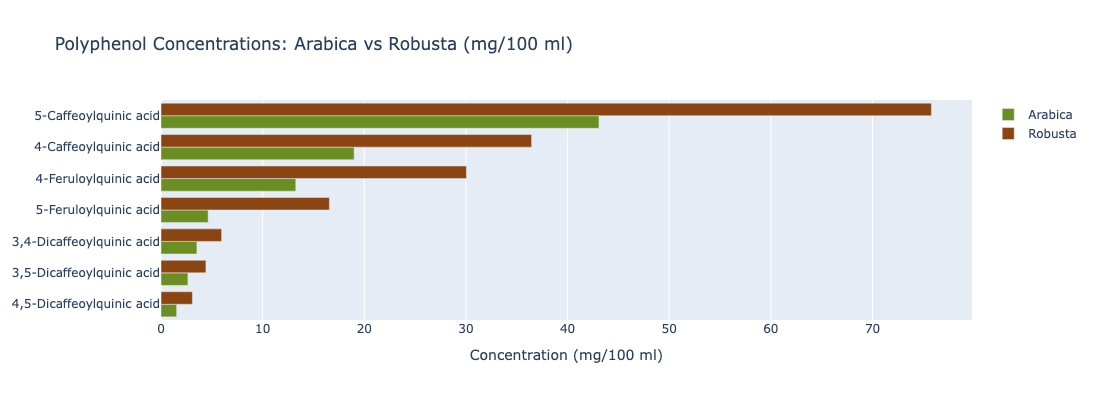

In [3]:
# Arabica vs Robusta polyphenol comparison (Phenol-Explorer)
arab_pe = phenol[phenol["food_name"] == "Arabica coffee beverage [Filter]"].set_index("compound_name")["mean_content"]
rob_pe = phenol[phenol["food_name"] == "Robusta coffee beverage [Filter]"].set_index("compound_name")["mean_content"]
both_pe = pd.DataFrame({"Arabica": arab_pe, "Robusta": rob_pe}).dropna().sort_values("Robusta", ascending=True)

fig = go.Figure()
fig.add_trace(go.Bar(name="Arabica", y=both_pe.index, x=both_pe["Arabica"], orientation="h", marker_color="#6B8E23"))
fig.add_trace(go.Bar(name="Robusta", y=both_pe.index, x=both_pe["Robusta"], orientation="h", marker_color="#8B4513"))
fig.update_layout(
    title="Polyphenol Concentrations: Arabica vs Robusta (mg/100 ml)",
    barmode="group", height=400,
    xaxis_title="Concentration (mg/100 ml)",
    yaxis=dict(categoryorder="total ascending"),
)
fig.show()

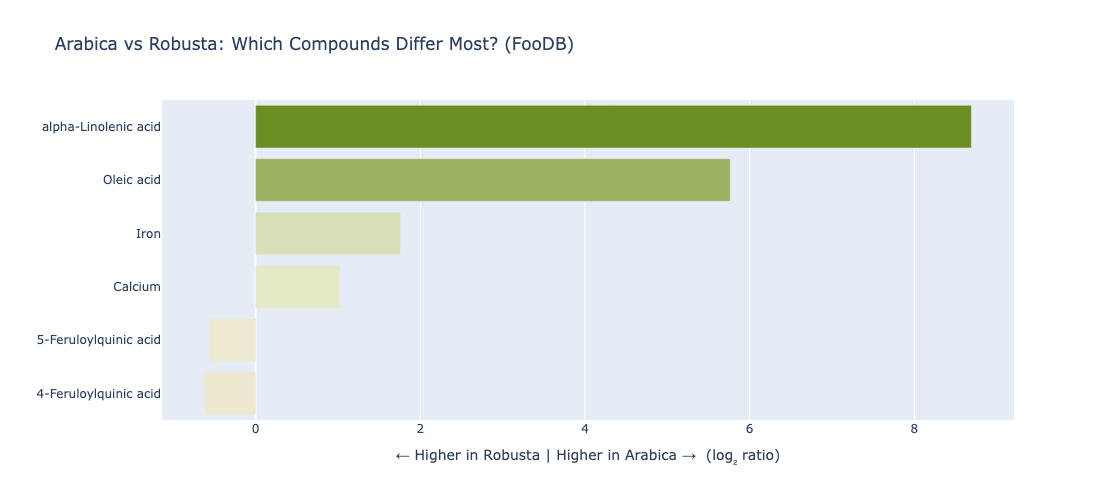

In [4]:
# Broader Arabica vs Robusta comparison from FooDB (larger compound set)
arabica = foodb[foodb["food_name"] == "Arabica coffee"].groupby("compound_name")["content"].mean().dropna()
robusta = foodb[foodb["food_name"] == "Robusta coffee"].groupby("compound_name")["content"].mean().dropna()
both = pd.DataFrame({"arabica": arabica, "robusta": robusta}).dropna()
both["ratio"] = both["arabica"] / both["robusta"].replace(0, np.nan)
both["log_ratio"] = np.log2(both["ratio"])

# Focus on compounds with meaningful concentrations and divergent ratios
sig = both[(both["arabica"] > 1) | (both["robusta"] > 1)].copy()
sig = sig[sig["log_ratio"].abs() > 0.3]  # >1.23x difference
sig = sig.sort_values("log_ratio")

fig = px.bar(
    sig.reset_index(),
    x="log_ratio", y="compound_name",
    orientation="h",
    title="Arabica vs Robusta: Which Compounds Differ Most? (FooDB)",
    labels={"log_ratio": "← Higher in Robusta | Higher in Arabica →  (log₂ ratio)", "compound_name": ""},
    color="log_ratio",
    color_continuous_scale=["#8B4513", "#f5f5dc", "#6B8E23"],
    color_continuous_midpoint=0,
)
fig.update_layout(height=500, yaxis=dict(categoryorder="total ascending"), coloraxis_showscale=False)
fig.show()

**Key finding: Robusta has 1.5–2x higher chlorogenic acid concentrations than Arabica**
across all CGA subtypes (5-CQA, 4-CQA, feruloylquinic acids). This is well-documented
in the literature and explains Robusta's more bitter, astringent cup profile.

Arabica, however, is dramatically higher in **alpha-linolenic acid** (an omega-3 fatty acid,
~400x more), **oleic acid** (~54x), and **beta-carotene** (~95x). These lipid differences
affect mouthfeel (body) and may explain why Arabica produces a richer, more complex cup.

**Caffeine** is ~18% higher in Arabica in our FooDB data, though the literature typically
reports Robusta as higher — this may reflect different preparation methods in the source studies.

> **Implication for Nogales:** Different Arabica *varieties* likely show similar but smaller
> chemical divergences. If Geisha's mucilage has different sugar/acid ratios than Bourbon's,
> that feeds different microbes during fermentation, producing different metabolites.

---

## 3. The Five Key Bioactive Compounds — Why They Matter

Coffee contains hundreds of compounds, but five have the most documented
pharmacological activity. Here's what they are and what the bioassay data
shows about their therapeutic potential.

In [5]:
# Compound properties overview
display_props = props[["compound_name", "MolecularWeight", "XLogP", "TPSA", "HBondDonorCount", "HBondAcceptorCount"]].copy()
display_props.columns = ["Compound", "Mol. Weight", "LogP", "Polar Surface Area", "H-Bond Donors", "H-Bond Acceptors"]
display_props["Compound"] = display_props["Compound"].str.replace("_", " ").str.title()

# Add bioassay summary
for compound in props["compound_name"]:
    active = bioassays[(bioassays["compound_name"] == compound) & (bioassays["activity_outcome"] == "Active")]
    total = bioassays[bioassays["compound_name"] == compound]
    display_props.loc[display_props["Compound"] == compound.replace("_", " ").title(), "Active Assays"] = len(active)
    display_props.loc[display_props["Compound"] == compound.replace("_", " ").title(), "Total Assays"] = len(total)
    display_props.loc[display_props["Compound"] == compound.replace("_", " ").title(), "Hit Rate"] = f"{len(active)/len(total)*100:.1f}%" if len(total) > 0 else "N/A"

# Add ChEMBL counts
for compound in chembl["compound_name"].unique():
    c_data = chembl[chembl["compound_name"] == compound]
    label = compound.replace("_", " ").title()
    display_props.loc[display_props["Compound"] == label, "ChEMBL Records"] = len(c_data)

display_props

,Compound,Mol. Weight,LogP,Polar Surface Area,H-Bond Donors,H-Bond Acceptors,Active Assays,Total Assays,Hit Rate,ChEMBL Records
0,Chlorogenic Acid,354.31,-0.4,165.0,6,9,54.0,1194.0,4.5%,265.0
1,Cafestol,316.40,3.3,53.6,2,3,0.0,31.0,0.0%,19.0
2,Kahweol,314.40,3.4,53.6,2,3,0.0,47.0,0.0%,3.0
3,Trigonelline,137.14,1.2,44.0,0,2,3.0,592.0,0.5%,22.0
4,Caffeine,194.19,-0.1,58.4,0,3,99.0,3646.0,2.7%,3024.0


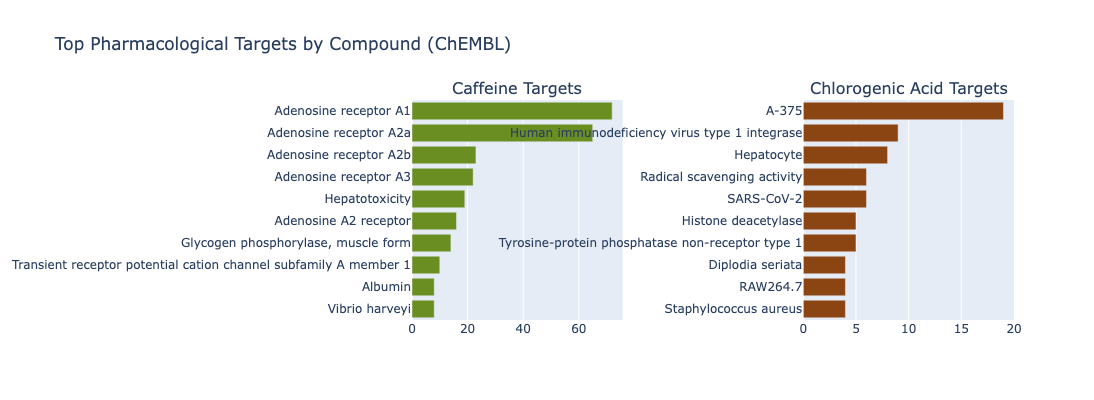

In [6]:
# What targets do these compounds hit? (ChEMBL data)
# Filter to meaningful targets (not generic organism-level)
skip_targets = {"Rattus norvegicus", "Mus musculus", "Homo sapiens", "ADMET",
                "Unchecked", "No relevant target", "NON-PROTEIN TARGET"}
targeted = chembl[
    chembl["target_pref_name"].notna() &
    ~chembl["target_pref_name"].isin(skip_targets)
].copy()

# Top targets per compound
fig = make_subplots(rows=1, cols=2, subplot_titles=("Caffeine Targets", "Chlorogenic Acid Targets"),
                    horizontal_spacing=0.3)

for i, compound in enumerate(["caffeine", "chlorogenic_acid"]):
    comp_data = targeted[targeted["compound_name"] == compound]
    top = comp_data["target_pref_name"].value_counts().head(10)
    fig.add_trace(
        go.Bar(y=top.index, x=top.values, orientation="h", name=compound.replace("_", " ").title(),
               marker_color=["#6B8E23", "#8B4513"][i]),
        row=1, col=i+1
    )

fig.update_layout(height=400, title="Top Pharmacological Targets by Compound (ChEMBL)", showlegend=False)
fig.update_yaxes(autorange="reversed")
fig.show()

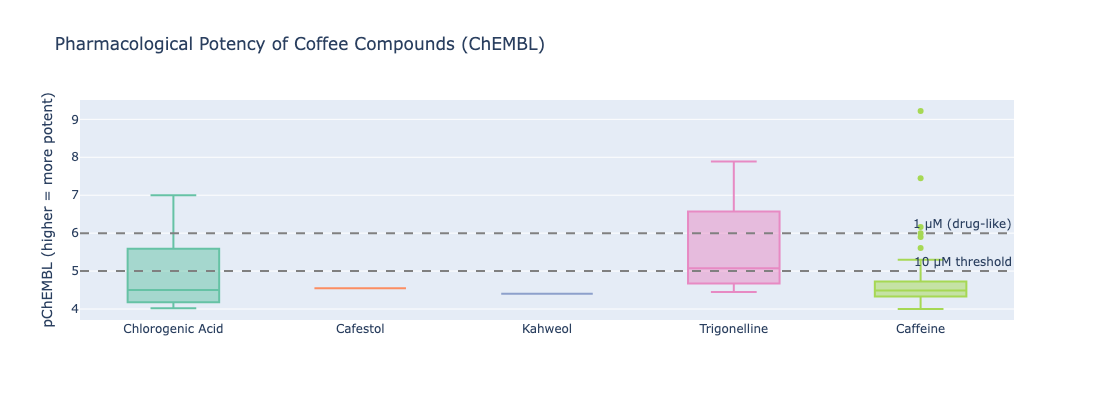


Potency summary (pChEMBL values — higher is more potent):
                  count      mean   min   max
compound_label                               
Cafestol            1.0  4.550000  4.55  4.55
Caffeine          197.0  4.581929  4.00  9.22
Chlorogenic Acid   27.0  4.940000  4.02  7.00
Kahweol             1.0  4.400000  4.40  4.40
Trigonelline        4.0  5.622500  4.45  7.89


In [7]:
# Potency comparison across compounds (pChEMBL values)
# pChEMBL = -log10(IC50/EC50/Ki in M). Higher = more potent. 5 = 10µM, 6 = 1µM, 7 = 100nM
potent = chembl[chembl["pchembl_value"].notna()].copy()
potent["compound_label"] = potent["compound_name"].str.replace("_", " ").str.title()

fig = px.box(
    potent, x="compound_label", y="pchembl_value",
    title="Pharmacological Potency of Coffee Compounds (ChEMBL)",
    labels={"pchembl_value": "pChEMBL (higher = more potent)", "compound_label": ""},
    color="compound_label",
    color_discrete_sequence=px.colors.qualitative.Set2,
)
fig.add_hline(y=5, line_dash="dash", line_color="gray", annotation_text="10 µM threshold")
fig.add_hline(y=6, line_dash="dash", line_color="gray", annotation_text="1 µM (drug-like)")
fig.update_layout(height=400, showlegend=False)
fig.show()

print(f"\nPotency summary (pChEMBL values — higher is more potent):")
print(potent.groupby("compound_label")["pchembl_value"].describe()[["count", "mean", "min", "max"]].to_string())

**What this shows:**

- **Caffeine** is the most pharmacologically characterized coffee compound (3,024 ChEMBL records,
  99 active PubChem assays). Its primary targets are **adenosine receptors A1, A2a, A2b, A3** —
  this is the mechanism behind alertness and cognitive enhancement. Some activity reaches
  pChEMBL ~9 (sub-nanomolar potency).

- **Chlorogenic acid** has 265 ChEMBL records and 54 active PubChem assays. It shows activity
  against **SARS-CoV-2** targets (16 records) and **hepatotoxicity** pathways (19 records),
  plus general antioxidant activity. Maximum potency reaches pChEMBL 7.0 (100 nM — drug-like).

- **Trigonelline** has limited but promising data — only 22 ChEMBL records but reaches pChEMBL 7.89
  (the highest max potency of any coffee compound in our data). Neuroprotective mechanisms.

- **Cafestol and kahweol** (the diterpenes) have sparse bioactivity data (19 and 3 records)
  but are known from the literature for anti-inflammatory and anti-cancer mechanisms.
  These are largely retained through roasting but removed by paper filtration.

> **Implication:** Chlorogenic acid and trigonelline are the compounds most worth tracking
> through the fermentation-to-roasting pipeline, because they're both pharmacologically
> active AND processing-sensitive. Cafestol/kahweol matter too but are less affected by
> fermentation specifically.

---

## 4. The Variety Landscape — Quality, Yield, and the Geisha Effect

The World Coffee Research catalog covers 70 arabica varieties with agronomic
ratings. A key question: **is there a quality-yield tradeoff, and do the
varieties that score highest in competitions match WCR's quality ratings?**

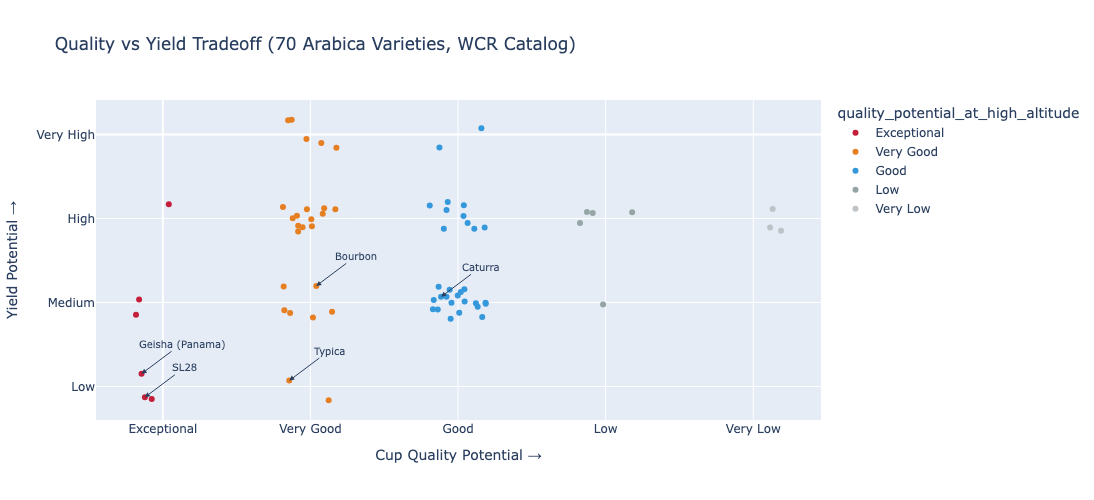

In [8]:
# Quality vs Yield tradeoff
quality_order = ["Exceptional", "Very Good", "Good", "Low", "Very Low"]
yield_order = ["Very High", "High", "Medium", "Low"]

wcr_plot = wcr[
    wcr["quality_potential_at_high_altitude"].isin(quality_order) &
    wcr["yield_potential"].isin(yield_order)
].copy()

# Create scatter with jitter
quality_num = {v: i for i, v in enumerate(quality_order)}
yield_num = {v: i for i, v in enumerate(yield_order)}
wcr_plot["quality_num"] = wcr_plot["quality_potential_at_high_altitude"].map(quality_num)
wcr_plot["yield_num"] = wcr_plot["yield_potential"].map(yield_num)

# Add jitter for visibility
np.random.seed(42)
wcr_plot["quality_jitter"] = wcr_plot["quality_num"] + np.random.uniform(-0.2, 0.2, len(wcr_plot))
wcr_plot["yield_jitter"] = wcr_plot["yield_num"] + np.random.uniform(-0.2, 0.2, len(wcr_plot))

fig = px.scatter(
    wcr_plot, x="quality_jitter", y="yield_jitter",
    hover_name="name", hover_data=["lineage"],
    title="Quality vs Yield Tradeoff (70 Arabica Varieties, WCR Catalog)",
    labels={"quality_jitter": "Cup Quality Potential →", "yield_jitter": "Yield Potential →"},
    color="quality_potential_at_high_altitude",
    color_discrete_map={"Exceptional": "#c41e3a", "Very Good": "#e67e22", "Good": "#3498db", "Low": "#95a5a6", "Very Low": "#bdc3c7"},
    category_orders={"quality_potential_at_high_altitude": quality_order},
)
fig.update_xaxes(tickvals=list(range(5)), ticktext=quality_order)
fig.update_yaxes(tickvals=list(range(4)), ticktext=yield_order, autorange="reversed")
fig.update_layout(height=500)

# Annotate notable varieties
for _, row in wcr_plot[wcr_plot["name"].isin(["Geisha (Panama)", "SL28", "Bourbon", "Caturra", "Typica"])].iterrows():
    fig.add_annotation(x=row["quality_jitter"], y=row["yield_jitter"], text=row["name"],
                       showarrow=True, arrowhead=2, ax=40, ay=-30, font=dict(size=10))
fig.show()

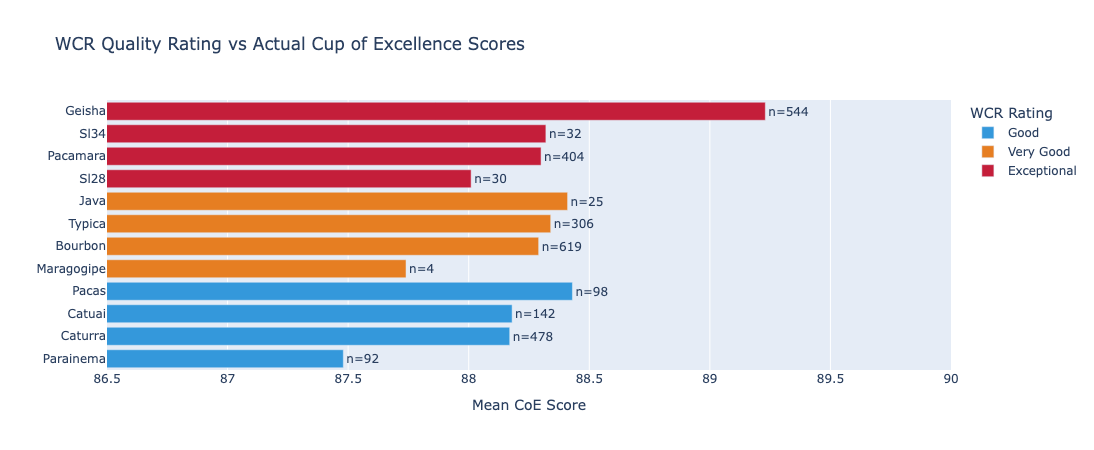

In [9]:
# Cross-reference: Do WCR quality ratings predict actual competition scores?
if coe is not None:
    results = []
    for name in ["bourbon", "typica", "caturra", "catuai", "geisha", "sl28", "sl34",
                 "castillo", "pacamara", "pacas", "java", "maragogipe", "parainema"]:
        wcr_match = wcr[wcr["name"].str.lower().str.contains(name, na=False)]
        coe_match = coe[coe["variety"].str.lower().str.contains(name, na=False)]
        if len(wcr_match) and len(coe_match):
            results.append({
                "variety": name.title(),
                "wcr_quality": wcr_match.iloc[0]["quality_potential_at_high_altitude"],
                "coe_mean_score": round(coe_match["score"].mean(), 2),
                "n_lots": len(coe_match),
            })

    xref = pd.DataFrame(results)
    quality_colors = {"Exceptional": "#c41e3a", "Very Good": "#e67e22", "Good": "#3498db"}

    fig = px.bar(
        xref.sort_values("coe_mean_score", ascending=True),
        x="coe_mean_score", y="variety", color="wcr_quality",
        orientation="h",
        title="WCR Quality Rating vs Actual Cup of Excellence Scores",
        labels={"coe_mean_score": "Mean CoE Score", "variety": "", "wcr_quality": "WCR Rating"},
        color_discrete_map=quality_colors,
        text="n_lots",
    )
    fig.update_traces(texttemplate="n=%{text}", textposition="outside")
    fig.update_layout(height=450, xaxis_range=[86.5, 90])
    fig.show()

**The quality-yield tradeoff is real but not absolute.**

The 6 "Exceptional" quality varieties (Geisha, SL28, SL34, Pacamara, Mibirizi, Casiopea)
are mostly low-to-medium yield. The 8 "Low/Very Low" quality varieties are all high-yield
Catimor/Sarchimor types bred for rust resistance — quality was sacrificed for disease
tolerance and productivity. But some varieties break the tradeoff: **Casiopea** (Exceptional
quality, High yield) and several F1 hybrids (Very Good quality, Very High yield).

**Geisha dominates competitions.** At 89.23 mean CoE score (n=544 lots), Geisha is a full
point above every other variety. The WCR "Exceptional" rating is validated — but the
separation is narrower among "Very Good" and "Good" varieties in CoE data, because
competitions pre-filter to top lots.

> **For Nogales:** The variety planted determines a quality ceiling, but processing is what
> gets you there. Geisha has the highest ceiling. Bourbon and Typica are reliably "Very Good."
> Caturra and Catuai are "Good" but can compete when processing is optimized — their CoE
> averages are only ~0.1-0.2 pts below Bourbon.

---

## 5. The Full Chemical Inventory — What Else Is in There?

FooDB gives us the broadest view: 16,340 compound-food records covering
everything from amino acids to fatty acids to vitamins. What compound
classes dominate, and what's unique to coffee?

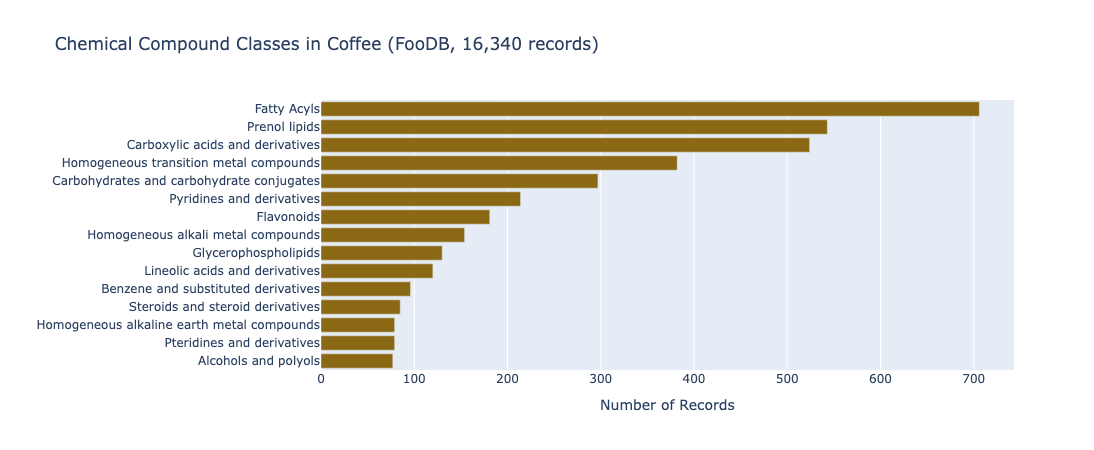

Unique compounds per coffee type:
food_name
Arabica coffee    4500
Coffee             172
Coffee mocha        39
Robusta coffee    4450


In [10]:
# Compound class breakdown (FooDB)
class_counts = foodb["klass"].value_counts().head(15)

fig = px.bar(
    class_counts.reset_index(),
    x="count", y="klass",
    orientation="h",
    title="Chemical Compound Classes in Coffee (FooDB, 16,340 records)",
    labels={"count": "Number of Records", "klass": ""},
    color_discrete_sequence=["#8B6914"],
)
fig.update_layout(height=450, yaxis=dict(categoryorder="total ascending"))
fig.show()

# Unique compounds per coffee type
unique_compounds = foodb.groupby("food_name")["compound_name"].nunique()
print("Unique compounds per coffee type:")
print(unique_compounds.to_string())

---

## 6. What This Means — Connecting Chemistry to the Farm

### Summary of findings

| Finding | Source | Strength |
|---------|--------|----------|
| Coffee polyphenols are dominated by 3 caffeoylquinic acids (~180 mg/cup combined) | Phenol-Explorer | Strong — direct measurement |
| Robusta has 1.5-2x higher CGA concentrations than Arabica | Phenol-Explorer, FooDB | Strong — consistent across databases |
| Arabica has dramatically higher lipid content (oleic acid, linolenic acid) | FooDB | Observed — may reflect preparation method differences |
| Chlorogenic acid reaches drug-like potency (pChEMBL 7.0 = 100 nM) | ChEMBL | Observed — in vitro, not clinical |
| Trigonelline has the highest max potency (pChEMBL 7.89) but sparse data | ChEMBL | Weak — only 4 measurements with potency data |
| Caffeine's primary targets are adenosine receptors A1/A2a/A2b/A3 | ChEMBL | Strong — 3,024 records, well-characterized |
| Quality-yield tradeoff is real: Exceptional varieties mostly Low-Medium yield | WCR | Strong — 70 varieties cataloged |
| Geisha scores 1+ point above all other varieties in CoE (89.23, n=544) | WCR + CoE | Strong — large sample, consistent |
| WCR quality ratings broadly predict CoE scores, but separation narrows at top | WCR + CoE | Moderate — correlation weakened by CoE's pre-filtering |

### What to measure at Nogales

Based on this reference data, the compounds most worth tracking through the
harvest-to-cup pipeline are:

1. **Chlorogenic acids (especially 5-CQA)** — highest concentration, most processing-sensitive, pharmacologically active
2. **Trigonelline** — neuroprotective, partially converts to niacin during roasting
3. **Caffeine** — stable through processing but varies by variety
4. **Lipid profile (oleic/linolenic acids)** — affects mouthfeel and body, varies dramatically between species and likely between varieties
5. **Microbial metabolites** — the fermentation-specific compounds not present in the cherry (organic acids, esters, alcohols) — this is the data that doesn't exist yet

### Data sources

| Dataset | Records | What it provides |
|---------|---------|-----------------|
| [Phenol-Explorer](http://phenol-explorer.eu) | 69 | Polyphenol concentrations for 4 coffee types |
| [FooDB](https://foodb.ca) | 16,340 | Full chemical inventory for Arabica, Robusta, general coffee |
| [PubChem](https://pubchem.ncbi.nlm.nih.gov) | 5,510 | Bioassay results for 5 key compounds |
| [ChEMBL](https://www.ebi.ac.uk/chembl/) | 3,333 | Bioactivity measurements against protein targets |
| [World Coffee Research](https://varieties.worldcoffeeresearch.org) | 70 | Arabica variety agronomic profiles |
| CQI | 1,311 | Cupping scores with variety/processing |
| Cup of Excellence | 17,211 | Competition scores with variety/farm |